# 02 — Training: all three conditions

Runs `base`, `sft_only`, and `distilled` through the same script
(`src/adbench/training/train.py`) — this notebook only orchestrates; all
the actual logic (config resolution, the per-step KD+SFT loss, data
formatting, the training loop) lives in `adbench.training.train` and
`adbench.training.losses`, and is unit-tested locally (`tests/test_train.py`,
`tests/test_losses.py`) without needing a GPU.

Requires `01_data_prep.ipynb` to have been run first (needs
`data/splits/train.jsonl`), and `00_setup_colab.ipynb` for the GPU deps.

In [14]:
# Public repo — no auth needed to clone. Skips re-cloning if this
# session's runtime already has the repo (e.g. you ran
# 00_setup_colab.ipynb earlier in this same session).
import os
import sys

# Reduces CUDA OOM from a single large allocation (e.g. loading the 14B
# teacher) by letting the allocator grow a segment incrementally instead of
# needing one big contiguous block upfront.
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

ON_KAGGLE = os.path.isdir('/kaggle')
REPO_DIR = '/kaggle/working/agentic-distillation-benchmark' if ON_KAGGLE else '/content/agentic-distillation-benchmark'

if not os.path.isdir(REPO_DIR):
    !git clone https://github.com/Nahla-Nabil/agentic-distillation-benchmark.git {REPO_DIR}

os.chdir(REPO_DIR)
!pip install -q -r requirements-colab.txt

# Put src/ on sys.path (for `import adbench` right here in this kernel)
# AND on PYTHONPATH (for `!python -m adbench...` subprocess calls in later
# cells, which inherit the environment but not this process's sys.path)
# instead of `pip install -e .` — an editable install registers itself via
# a .pth file that Python's site module only reads at interpreter startup,
# so `import adbench` fails with ModuleNotFoundError in this same
# still-running kernel until you restart it. Both of the below work
# immediately, no restart needed, on Colab or Kaggle.
src_path = os.path.join(REPO_DIR, 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)
os.environ['PYTHONPATH'] = src_path + os.pathsep + os.environ.get('PYTHONPATH', '')

In [15]:
# Re-run this any time (after I've pushed a fix) to sync this session's
# cloned repo to the latest on GitHub, without re-cloning or restarting.
!cd {REPO_DIR} && git checkout -- . && git pull

remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 22 (delta 14), reused 16 (delta 10), pack-reused 0 (from 0)
Unpacking objects: 100% (22/22), 10.15 KiB | 1.13 MiB/s, done.
From https://github.com/Nahla-Nabil/agentic-distillation-benchmark
   2f5387c..a954536  master     -> origin/master
Updating 2f5387c..a954536
Fast-forward
 notebooks/00_setup_colab.ipynb    | 165 +++++++++++++++++--------------------
 notebooks/01_data_prep.ipynb      | 166 +++++++++++++++-----------------------
 notebooks/02_training.ipynb       |  12 +++
 notebooks/03_evaluate.ipynb       |  12 +++
 notebooks/04_layer_analysis.ipynb |  12 +++
 src/adbench/training/train.py     |  25 +++++-
 6 files changed, 199 insertions(+), 193 deletions(-)


In [16]:
from adbench.training.train import load_experiment_config, train_condition

experiment_config = load_experiment_config("configs/experiment.yaml")
models_config = load_experiment_config("configs/models.yaml")

## Condition 1 — base (no training)

Loads the student, attaches a freshly-initialized (untrained) LoRA adapter,
saves immediately — see `train.py::save_checkpoint()`'s docstring for why
this condition still goes through the same load+save path as the other two
rather than being special-cased in evaluation.

In [17]:
!python -m adbench.training.train --condition base

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.9.4: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Loading weights: 100%|███████████████████████| 398/398 [00:01<00:00, 208.42it/s]
Unsloth 2026.9.4 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/agentic-distillation-benchmark/checkpoints/base/tokenizer_config.json.
{
  "condition": "base",
  "checkpoint_dir": "/kaggle/working/agentic-distillation-benchmark/checkpoints/ba

In [18]:
!python -m adbench.data.prepare --config configs/data.yaml

Refusing to overwrite an existing split (/kaggle/working/agentic-distillation-benchmark/data/splits/train.jsonl / /kaggle/working/agentic-distillation-benchmark/data/splits/test.jsonl). The test split is frozen once written so train/test never leak across experiments — pass --force if you deliberately want to regenerate both.


## Condition 2 — sft_only (control)

Standard SFT on `data/splits/train.jsonl`, no teacher involved —
`resolve_training_config` forces `kd_weight=0` for this condition
regardless of `configs/experiment.yaml`'s `training.kd` block, so it can
never accidentally depend on the teacher.

It appears that the `train.jsonl` file, which is necessary for the `sft_only` condition, is missing. This file is generated by running `01_data_prep.ipynb`. Please ensure you have run that notebook first before proceeding.

In [19]:
!python -m adbench.training.train --condition sft_only

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.9.4: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Loading weights: 100%|███████████████████████| 398/398 [00:01<00:00, 202.12it/s]
Unsloth 2026.9.4 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.
`use_return_dict` is deprecated! Use `return_dict` instead!
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/agentic-distillation-benchmark/checkpoints/sft_only/tokenizer_config.json.
{
  "condition": "sft_only",
  "checkpoint_

## Condition 3 — distilled (treatment)

Combined KD (from the teacher) + SFT loss. Same data/LoRA/optimizer
settings as `sft_only` — only the loss function differs.

To try a named hyperparameter variation instead of the base `training.kd`
values (configs/experiment.yaml: `training.sweep`), pass `sweep_name=`:
```python
train_condition("distilled", experiment_config, models_config, sweep_name="higher_kd_temp")
```

In [20]:
!cd /content/agentic-distillation-benchmark && git checkout -- . && git pull


/bin/bash: line 1: cd: /content/agentic-distillation-benchmark: No such file or directory


In [21]:
!python -m adbench.training.train --condition distilled
# For a named hyperparameter variation instead (configs/experiment.yaml: training.sweep):
# !python -m adbench.training.train --condition distilled --sweep higher_kd_temp

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.9.4: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Loading weights: 100%|███████████████████████| 398/398 [00:01<00:00, 214.31it/s]
Unsloth 2026.9.4 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.
==((====))==  Unsloth 2026.9.4: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /   

## Sanity-check convergence before moving to evaluation

`sft_only` and `distilled` each wrote a per-step loss log to
`results/training_logs/<condition>.jsonl` (`sft_loss`/`kd_loss`/`total_loss`
logged separately — see `train.py::run_training_loop`). Plot them side by
side before spending eval time on a run that didn't converge.

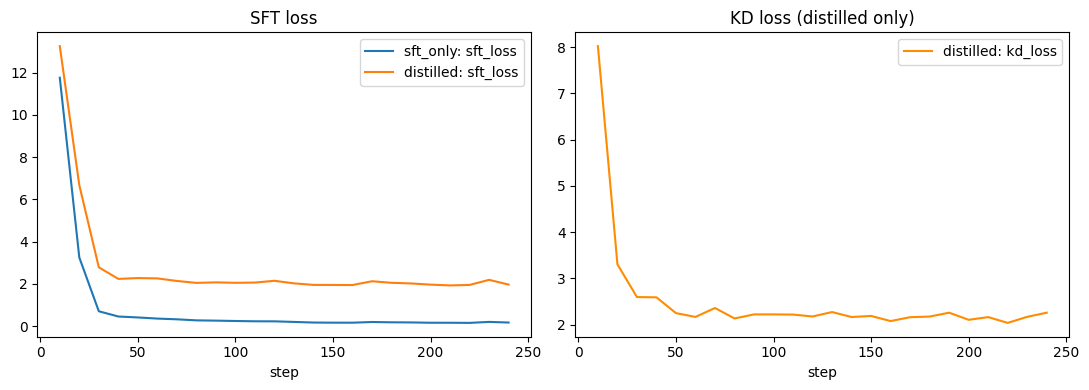

In [22]:
import matplotlib.pyplot as plt

from adbench.data.prepare import read_jsonl
from adbench.training.train import loss_log_path

sft_log = read_jsonl(loss_log_path("sft_only"))
distilled_log = read_jsonl(loss_log_path("distilled"))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot([r["step"] for r in sft_log], [r["sft_loss"] for r in sft_log], label="sft_only: sft_loss")
axes[0].plot([r["step"] for r in distilled_log], [r["sft_loss"] for r in distilled_log], label="distilled: sft_loss")
axes[0].set_title("SFT loss")
axes[0].set_xlabel("step")
axes[0].legend()

axes[1].plot([r["step"] for r in distilled_log], [r["kd_loss"] for r in distilled_log], label="distilled: kd_loss", color="darkorange")
axes[1].set_title("KD loss (distilled only)")
axes[1].set_xlabel("step")
axes[1].legend()
plt.tight_layout()
plt.show()